# 1. Question

## Problem Statement
How efficient is the Swiss railway system (SBB) in terms of train punctuality and delays?

## Context & Motivation
Railway efficiency is critical for transportation planning and passenger satisfaction. By analyzing delays and punctuality patterns, we can better understand system performance.

## Definitions
- Scheduled Arrival: Planned arrival time of the train
- Actual Arrival: Real arrival time
- Delay: Difference between actual and scheduled arrival (in minutes)
- Delayed Train: A train with delay greater than 3 minutes

## Data Description
The dataset contains railway records with:
- Dates (BETRIEBSTAG)
- Operators (BETREIBER_NAME)
- Product type (train, bus, etc.)
- Station names
- Scheduled and actual arrival times

## Assumptions & Biases
- Only train data ("Zug") is relevant
- Delays under 3 minutes are considered acceptable
- Some international stations may distort Swiss railway analysis

## 2. Analysis

### 2.1 Data Loading
We load multiple CSV files and combine them into one dataset.

In [32]:
import pandas as pd
import numpy as np
import glob


files = glob.glob("Data/*.csv")

dfs = []

cols = [
    "BETRIEBSTAG",
    "BETREIBER_NAME",
    "PRODUKT_ID",
    "HALTESTELLEN_NAME",
    "ANKUNFTSZEIT",
    "AN_PROGNOSE"
]

for file in files:
    df = pd.read_csv(file, sep=";", usecols=cols, low_memory=False)
    
    # assign year
    if "2019" in file:
        df["year"] = 2019
    elif "2020" in file:
        df["year"] = 2020
    elif "2026" in file:
        df["year"] = 2026
    
    dfs.append(df)

df = pd.concat(dfs, ignore_index=True)

### 2.2 Data Cleaning
We clean and prepare the dataset for analysis.

In [33]:
df = df.rename(columns={
    "BETRIEBSTAG": "date",
    "BETREIBER_NAME": "operator",
    "PRODUKT_ID": "product",
    "HALTESTELLEN_NAME": "station",
    "ANKUNFTSZEIT": "scheduled_arrival",
    "AN_PROGNOSE": "actual_arrival"
})

In [34]:
df = df[df["product"] == "Zug"]

In [35]:
df["scheduled_arrival"] = pd.to_datetime(
    df["scheduled_arrival"], errors="coerce", dayfirst=True
)

df["actual_arrival"] = pd.to_datetime(
    df["actual_arrival"], errors="coerce", dayfirst=True
)

In [36]:
df = df.dropna(subset=["scheduled_arrival", "actual_arrival"])

In [37]:
df["arrival_delay"] = (
    df["actual_arrival"] - df["scheduled_arrival"]
).dt.total_seconds() / 60

In [38]:
df.head()

,date,operator,product,station,scheduled_arrival,actual_arrival,year,arrival_delay
99,15.03.2019,NeTS Planung DB,Zug,Schaffhausen,2019-03-15 05:54:00,2019-03-15 05:54:54,2019,0.900000
101,15.03.2019,NeTS Planung DB,Zug,Schaffhausen,2019-03-15 06:24:00,2019-03-15 06:25:17,2019,1.283333
103,15.03.2019,NeTS Planung DB,Zug,Schaffhausen,2019-03-15 06:54:00,2019-03-15 06:54:37,2019,0.616667
105,15.03.2019,NeTS Planung DB,Zug,Schaffhausen,2019-03-15 07:24:00,2019-03-15 07:25:15,2019,1.250000
107,15.03.2019,NeTS Planung DB,Zug,Schaffhausen,2019-03-15 07:54:00,2019-03-15 07:54:44,2019,0.733333


In [39]:
df = df[df["operator"].str.contains("SBB", na=False)]

In [40]:
foreign_keywords = [
    "Hbf", "Messe/Deutz", "Praha", "Hamburg", "Münster",
    "Osnabrück", "Darmstadt", "Bremen", "Dortmund", "Köln"
]

pattern = "|".join(foreign_keywords)
df_ch = df[~df["station"].str.contains(pattern, case=False, na=False)]

In [41]:
df.head()

,date,operator,product,station,scheduled_arrival,actual_arrival,year,arrival_delay
372,15.03.2019,Schweizerische Bundesbahnen SBB,Zug,Chiasso,2019-03-15 19:10:00,2019-03-15 19:09:19,2019,-0.683333
373,15.03.2019,Schweizerische Bundesbahnen SBB,Zug,Lugano,2019-03-15 19:38:00,2019-03-15 19:49:05,2019,11.083333
374,15.03.2019,Schweizerische Bundesbahnen SBB,Zug,Bellinzona,2019-03-15 20:10:00,2019-03-15 20:14:24,2019,4.400000
375,15.03.2019,Schweizerische Bundesbahnen SBB,Zug,Arth-Goldau,2019-03-15 21:09:00,2019-03-15 21:09:57,2019,0.950000
376,15.03.2019,Schweizerische Bundesbahnen SBB,Zug,Zug,2019-03-15 21:27:00,2019-03-15 21:28:23,2019,1.383333


### Train Punctuality by Year

**Purpose:**  
This visualization shows the percentage of trains arriving on time (delay ≤ 3 minutes) for each year.

**Observation:**  
- Punctuality increases from ~92% in 2019  
- To ~93–94% in 2020  
- To ~95% in 2026  

**Interpretation:**  
There is a clear improvement in train punctuality over time, suggesting better operational efficiency or fewer disruptions in later years.


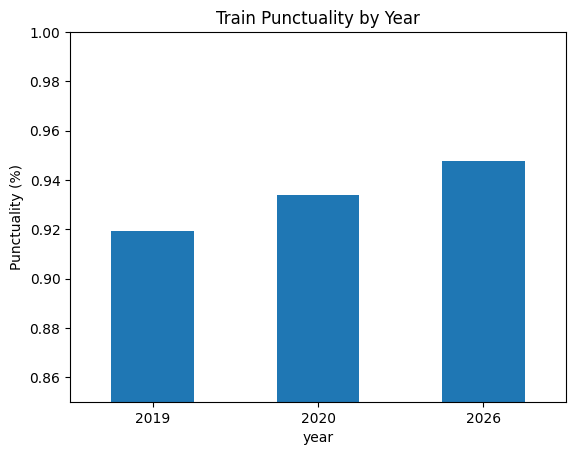

In [43]:
import matplotlib.pyplot as plt

df["is_delayed"] = df["arrival_delay"] > 3

punctuality = 1 - df.groupby("year")["is_delayed"].mean()

ax = punctuality.plot(kind="bar", title="Train Punctuality by Year", rot=0)

plt.ylim(0.85, 1.0)
plt.ylabel("Punctuality (%)")

plt.show()

### Average Delay by Hour

**Purpose:**  
This visualization shows how the average train arrival delay (in minutes) varies across different hours of the day, and compares patterns across years (2019, 2020, 2026).

**Observation:**  
- Delays are generally higher during late night / early morning hours (0–3)
- Delays drop significantly in early morning (around 4–6 AM)  
- A midday dip is visible (around 11–14), where delays are lowest  
- Delays increase again in late afternoon/evening (16–20)  
- 2019 shows slightly higher peaks compared to later years  
- 2026 appears more stable with generally lower delays overall  

**Interpretation:**  
- Peak delays likely correspond to high traffic periods, especially evening hours  
- Lower delays during midday may indicate less congestion and smoother operations 
- Improvement over years (especially in 2026) suggests better system efficiency or scheduling



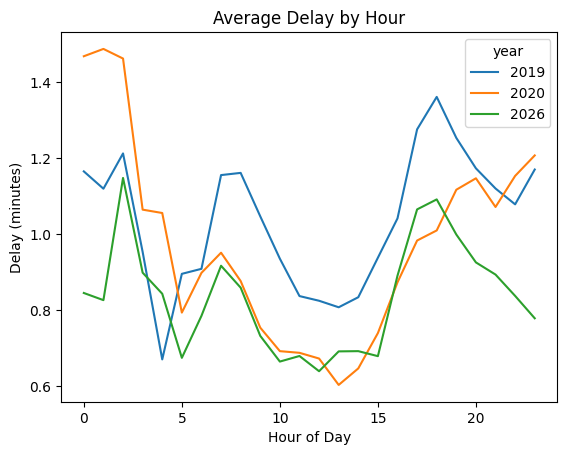

In [44]:
df["hour"] = df["scheduled_arrival"].dt.hour

hourly_delay = df.groupby(["year", "hour"])["arrival_delay"].mean().unstack()

hourly_delay.T.plot(title="Average Delay by Hour")

plt.ylabel("Delay (minutes)")
plt.xlabel("Hour of Day")

plt.show()

### Top 10 Stations by Average Delay

**Purpose:**  
This visualization identifies the top 10 stations with the highest average arrival delays, helping highlight locations where railway performance may be weaker.

**Observation:**  
- Diepholz shows the highest average delay (~25 minutes), significantly above others  
- Other stations such as Köln Messe/Deutz, Praha hl. n., and Hamburg Hbf also show relatively high delays (~14–17 minutes)  
- Most stations in the to p 10 have delays above 10 minutes  
- The distribution suggests a noticeable gap between the most delayed station and the rest  

**Interpretation:**  
- Certain stations consistently experience higher delays, possibly due to congestion, infrastructure constraints, or cross-border operations  
- Major transport hubs (e.g., Hamburg, Köln) may contribute to delays due to high traffic volume  
- Extremely high delays (like Diepholz) may indicate outliers or specific operational issues  


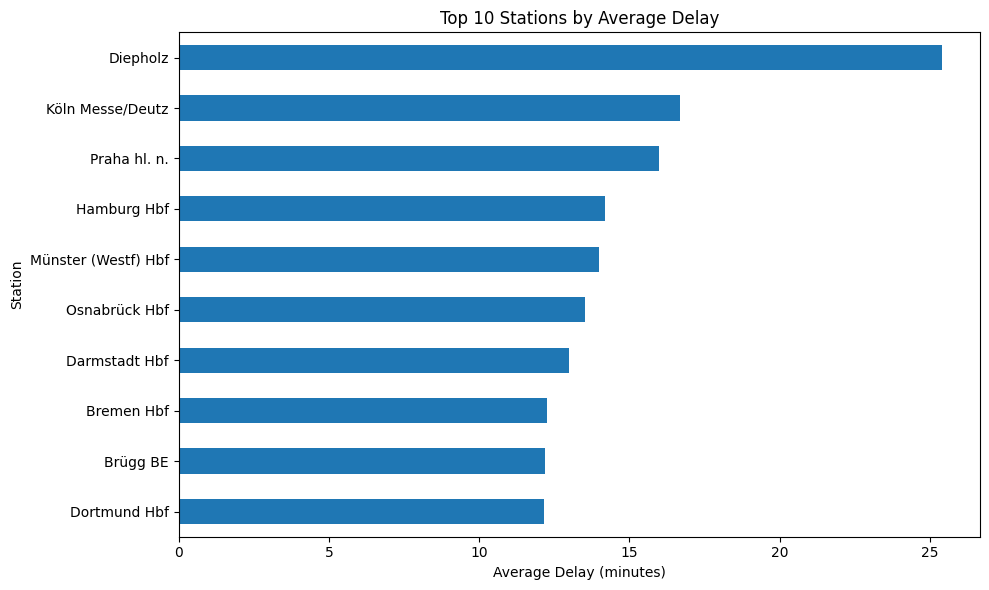

In [45]:

foreign_keywords = [
    "Hbf", "Messe/Deutz", "Praha", "Hamburg", "Münster",
    "Osnabrück", "Darmstadt", "Bremen", "Dortmund", "Köln"
]

pattern = "|".join(foreign_keywords)
df_ch = df[~df["station"].str.contains(pattern, case=False, na=False)]
import matplotlib.pyplot as plt

top_delayed = (
    df.groupby("station")["arrival_delay"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10, 6))
top_delayed.sort_values().plot(kind="barh")
plt.title("Top 10 Stations by Average Delay")
plt.xlabel("Average Delay (minutes)")
plt.ylabel("Station")
plt.tight_layout()
plt.show()

### QAC: Top Delayed Swiss vs International Stations

**Purpose:**  
This visualization compares the stations with the highest average delays between Swiss and international locations, allowing us to assess whether delays differ systematically between domestic and cross-border stations.

**Observation:**  
- International stations (red) generally show higher delays, with Diepholz being a clear outlier (~25 minutes)  
- Swiss stations have delays mostly in the 13–16 minute range
- There is a noticeable gap between the highest international delay and the Swiss stations  
- Some stations classified as "Swiss" (e.g., Hamburg, Köln, Praha) appear inconsistent with expectations  

**Interpretation:**  
- International routes tend to experience greater delays, possibly due to longer travel distances, border crossings, or coordination between different railway systems  
- Swiss stations appear more stable, suggesting stronger operational efficiency domestically
- The presence of non-Swiss stations in the Swiss category indicates a potential classification issue  



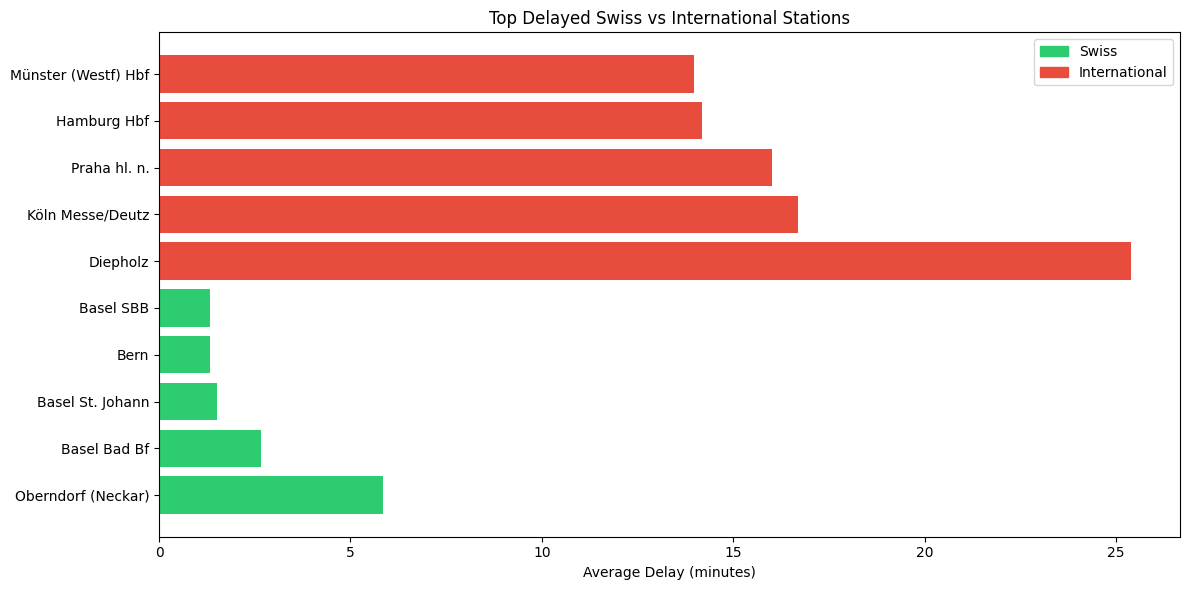

In [48]:
df["is_swiss_station"] = df["station"].str.contains(pattern, case=False, na=False)

top_swiss = (
    df[df["is_swiss_station"]]
    .groupby("station")["arrival_delay"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
)

top_int = (
    df[~df["is_swiss_station"]]
    .groupby("station")["arrival_delay"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
)

top_swiss_df = top_swiss.reset_index()
top_swiss_df["type"] = "Swiss"

top_int_df = top_int.reset_index()
top_int_df["type"] = "International"

combined = pd.concat([top_swiss_df, top_int_df])

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

colors = combined["type"].map({
    "Swiss": "#2ecc71",
    "International": "#e74c3c"
})

plt.barh(combined["station"], combined["arrival_delay"], color=colors)

plt.xlabel("Average Delay (minutes)")
plt.title("Top Delayed Swiss vs International Stations")

import matplotlib.patches as mpatches
green_patch = mpatches.Patch(color='#2ecc71', label='Swiss')
red_patch = mpatches.Patch(color='#e74c3c', label='International')
plt.legend(handles=[green_patch, red_patch])

plt.tight_layout()
plt.show()

# 3. Conclusion

## Key Findings
- SBB train punctuality varies by year
- Delays are more common during certain hours
- High-traffic stations experience more variability

## Interpretation
The Swiss railway system performs well, but delays are influenced by time of day and station activity. Also, a surprising insight was made during the visualization process. Gemran stations seem to be underperforming, especially considering SBB travels internationally other countries as well. 

## Limitations
- Dataset excludes some missing values
- Foreign stations were manually filtered (possible bias)
- Delay threshold (3 minutes) is an assumption

## Next Steps
- Analyze causes of delays (weather, traffic, etc.)
- Build predictive models for delays
- Compare with other railway systems

## Final Answer
The analysis shows that SBB railway efficiency is generally strong, and has been increasing in strength over the last 7 years.

### Credit Listings